In [5]:
from RL.trainer import SACTrajectoryTrainer

In [6]:
waypoints_manual = [{
    "x": 450.0,
    "y": 150.0,
    "z": 200.0,
    "v": 20.0
}, {
    "x": 800.0,
    "y": 430.0,
    "z": 200.0,
    "v": 15.0
}, {
    "x": 930.0,
    "y": 440.0,
    "z": 200.0,
    "v": 20.0
}, {
    "x": 950.0,
    "y": 950.0,
    "z": 10.0,
    "v": 20.0
}
]

[ SAC ]> Loading configuration from Settings/Test/rl_parameters_test_env.yaml


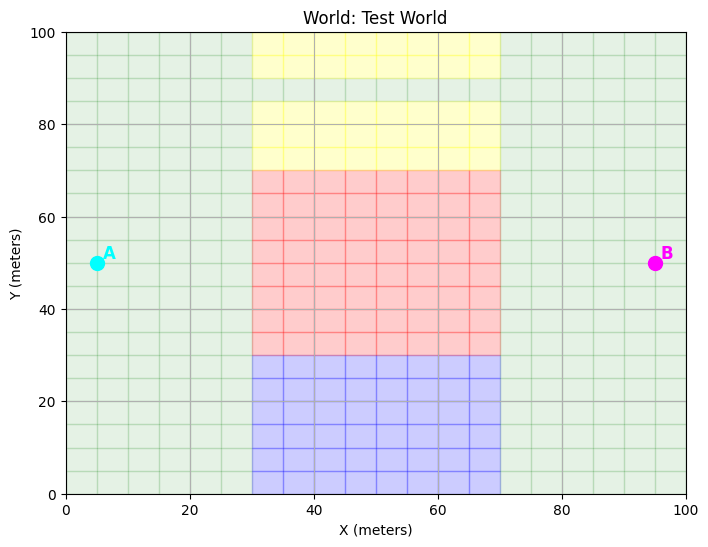

In [7]:
trainer = SACTrajectoryTrainer("Settings/Test/rl_parameters_test_env.yaml",
                               verbose=True,
                               # specific_waypoints=waypoints_manual,
                               run_zero_waypoint_episode=True)
trainer.simulation_object.world.plot_world_from_top(A=trainer.start_point,
                                                    B=trainer.end_point)

In [8]:
trainer.start_optimization()

[ SAC_COST ]> No configuration file provided, using default settings.


ValueError: Inconsistent action bounds: some waypoint intervals are invalid: [-30. -30. -30. -30. -30.] > [-34.09090909 -42.27272727 -50.45454545 -58.63636364 -66.81818182]

In [ ]:
best_params = trainer.best_params
print("Best parameters found by RL agent:", best_params)

In [ ]:
# Import best trajectory found by RL agent into main simulation for visualization and analysis
from main import *
from Optimizations.optimizer import Optimizer as CostWrapper
from Utils.plotting_functions import show2DWorld, plot3DAnimation


parameters = trainer.simulation_parameters
init_state = create_initial_state(*trainer.start_point)
waypoints_selected = best_params

thrust_max = get_max_thrust_from_rotor_model(parameters)
pid_gains = load_pid_gains(parameters)
quad_controller = create_quadcopter_controller(init_state, pid_gains, thrust_max, parameters)
drone = create_quadcopter_model(init_state, quad_controller, parameters)
world = World.load_world(parameters['world_data_path'])
noise_model = load_dnn_noise_model(parameters)

A = parameters['start_point']
B = parameters['end_point']

sim = Simulation(
    drone,
    world,
    waypoints_selected,
    dt=float(parameters['dt']),
    max_simulation_time=float(parameters['simulation_time']),
    frame_skip=int(parameters['frame_skip']),
    target_reached_threshold=float(parameters['threshold']),
    target_shift_threshold_distance=float(parameters['target_shift_threshold_distance']),
    noise_model=noise_model,
    generate_sound_emission_map=True,
    compute_psychoacoustics=False,
    noise_annoyance_radius=9,
)

cw = CostWrapper(sim, "")

cw.simulation_object.startSimulation(stop_at_target=True, use_static_target=False, verbose=True)
print(f"Costs: {cw.calculate_costs()}")
max_world_size = cw.simulation_object.world.max_world_size
show2DWorld(
    world, cw.simulation_object.positions, A, B, waypoints_selected)